In [8]:
import json
import numpy as np
import random
import pandas as pd
from pathlib import Path

KC_COLUMNS = [
    'If/Else', 'NestedIf', 'While', 'For', 'NestedFor',
    'Math+-*/', 'Math%', 'LogicAndNotOr', 'LogicCompareNum', 'LogicBoolean',
    'StringFormat', 'StringConcat', 'StringIndex', 'StringLen',
    'StringEqual', 'CharEqual', 'ArrayIndex', 'DefFunction'
]

TARGET_STUDENTS = [10155, 14476, 14475]
V3_DIR = Path('results/human_validation')
OUTPUT_DIR = Path('results/learning_curve')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

STRUGGLE_THRESHOLD = 1.0  # Below perfect = still struggling
ALT_STRUGGLE_THRESHOLD = 0.8

In [9]:
all_predictions = []
student_summaries = []
all_problems_by_student = {}

for sid in TARGET_STUDENTS:
    filepath = V3_DIR / f'llm_v3_annotations_{sid}.json'
    with open(filepath, 'r') as f:
        data = json.load(f)

    annotations = data['annotations']
    raw = data['raw_responses']

    problems = []
    for pid, info in raw.items():
        problems.append({
            'pid': pid,
            'score': float(info['score']),
            'required_kcs': list(info['required_kcs']),
            'assignment_id': int(info['assignment_id']),
            'gaps': annotations.get(pid, {}).get('gaps', []),
        })

    # Sort temporally: assignment_id (chapter order), then problem_id within chapter
    problems.sort(key=lambda x: (x['assignment_id'], int(x['pid'])))
    all_problems_by_student[sid] = problems

    n_total = len(problems)
    n_perfect = sum(1 for p in problems if p['score'] >= 1.0)
    n_with_gaps = sum(1 for p in problems if p['gaps'])
    n_nonperfect = n_total - n_perfect

    print(f'Student {sid}: {n_total} problems, {n_perfect} perfect, {n_nonperfect} non-perfect, {n_with_gaps} with gaps')

    student_preds = []

    # For each flagged gap KC, find the NEXT problem requiring that KC
    for i, current in enumerate(problems):
        if not current['gaps']:
            continue

        for gap_kc in current['gaps']:
            found = False
            for j in range(i + 1, len(problems)):
                future = problems[j]
                if gap_kc in future['required_kcs']:
                    still_struggling = future['score'] < STRUGGLE_THRESHOLD
                    pred = {
                        'SubjectID': sid,
                        'GapKC': gap_kc,
                        'SourceProblem': current['pid'],
                        'SourceScore': current['score'],
                        'SourceOrder': i,
                        'FutureProblem': future['pid'],
                        'FutureScore': future['score'],
                        'FutureOrder': j,
                        'StillStruggling': still_struggling,
                        'Prediction': 'TP' if still_struggling else 'FP',
                    }
                    student_preds.append(pred)
                    all_predictions.append(pred)
                    found = True
                    break

            if not found:
                all_predictions.append({
                    'SubjectID': sid,
                    'GapKC': gap_kc,
                    'SourceProblem': current['pid'],
                    'SourceScore': current['score'],
                    'SourceOrder': i,
                    'FutureProblem': None,
                    'FutureScore': None,
                    'FutureOrder': None,
                    'StillStruggling': None,
                    'Prediction': 'NO_FUTURE',
                })

    validatable = [p for p in student_preds if p['Prediction'] in ('TP', 'FP')]
    if validatable:
        tp = sum(1 for p in validatable if p['Prediction'] == 'TP')
        hit = tp / len(validatable)
        student_summaries.append({
            'SubjectID': sid,
            'Validatable': len(validatable),
            'TP': tp,
            'FP': len(validatable) - tp,
            'HitRate': round(hit, 3),
        })
        print(f'  -> {len(validatable)} validatable, hit rate: {hit:.1%}')
    else:
        student_summaries.append({
            'SubjectID': sid,
            'Validatable': 0,
            'TP': 0,
            'FP': 0,
            'HitRate': 0.0,
        })
        print('  -> no validatable predictions')

Student 10155: 46 problems, 11 perfect, 35 non-perfect, 14 with gaps
  -> 38 validatable, hit rate: 84.2%
Student 14476: 50 problems, 21 perfect, 29 non-perfect, 24 with gaps
  -> 52 validatable, hit rate: 82.7%
Student 14475: 50 problems, 45 perfect, 5 non-perfect, 5 with gaps
  -> 7 validatable, hit rate: 14.3%


In [10]:
pred_df = pd.DataFrame(all_predictions)
validatable = pred_df[pred_df['Prediction'].isin(['TP', 'FP'])].copy()

if len(validatable) > 0:
    tp = len(validatable[validatable['Prediction'] == 'TP'])
    fp = len(validatable[validatable['Prediction'] == 'FP'])
    hit_rate = tp / len(validatable)
else:
    tp = 0
    fp = 0
    hit_rate = 0.0

print('=== V3 Predictive Validation (3 Students) ===')
print(f'Validatable predictions: {len(validatable)}')
print(f'True Positives: {tp}')
print(f'False Positives: {fp}')
print(f'Hit Rate: {hit_rate:.3f} ({hit_rate * 100:.1f}%)')

print()
print(f"{'KC':<20} {'SrcP':>5} {'SrcSc':>6} -> {'FutP':>5} {'FutSc':>6} {'Result':>6}  Student")
print('-' * 72)
for _, p in validatable.sort_values(['SubjectID', 'SourceOrder']).iterrows():
    result = 'TP' if p['Prediction'] == 'TP' else 'FP'
    print(f"{p['GapKC']:<20} P{int(p['SourceProblem']):>4} {p['SourceScore']:>6.3f} -> "
          f"P{int(p['FutureProblem']):>4} {p['FutureScore']:>6.3f} {result:>6}  {p['SubjectID']}")

print()
print(f"{'KC':<20} {'TP':>4} {'FP':>4} {'Hit%':>7}")
print('-' * 38)
for kc in KC_COLUMNS:
    kc_data = validatable[validatable['GapKC'] == kc]
    if len(kc_data) > 0:
        kc_tp = len(kc_data[kc_data['Prediction'] == 'TP'])
        kc_hit = kc_tp / len(kc_data)
        print(f"{kc:<20} {kc_tp:>4} {len(kc_data)-kc_tp:>4} {kc_hit:>6.1%}")

print()
print('Per-Student:')
print(pd.DataFrame(student_summaries).to_string(index=False))

# Keep the validated results available for later cells.
pred_df.to_csv(OUTPUT_DIR / 'v3_predictions.csv', index=False)

=== V3 Predictive Validation (3 Students) ===
Validatable predictions: 97
True Positives: 76
False Positives: 21
Hit Rate: 0.784 (78.4%)

KC                    SrcP  SrcSc ->  FutP  FutSc Result  Student
------------------------------------------------------------------------
LogicAndNotOr        P   3  0.812 -> P  12  1.000     FP  10155
LogicAndNotOr        P 234  0.923 -> P 235  0.857     TP  10155
LogicAndNotOr        P 235  0.857 -> P 236  0.750     TP  10155
LogicCompareNum      P 235  0.857 -> P 236  0.750     TP  10155
If/Else              P 235  0.857 -> P 236  0.750     TP  10155
LogicAndNotOr        P 236  0.750 -> P  17  1.000     FP  10155
If/Else              P 236  0.750 -> P  17  1.000     FP  10155
DefFunction          P  22  0.360 -> P 100  0.071     TP  10155
Math+-*/             P  22  0.360 -> P  24  0.591     TP  10155
LogicCompareNum      P  22  0.360 -> P  24  0.591     TP  10155
LogicAndNotOr        P  22  0.360 -> P  24  0.591     TP  10155
If/Else            

In [11]:
random.seed(42)
NUM_TRIALS = 1000

# V3 gap-flagging rate
# Use required KCs as the denominator so this matches how the random baseline is sampled.
total_slots = 0
total_flagged = 0

for sid in TARGET_STUDENTS:
    filepath = V3_DIR / f'llm_v3_annotations_{sid}.json'
    with open(filepath, 'r') as f:
        data = json.load(f)

    for pid, info in data['raw_responses'].items():
        required = info['required_kcs']
        gaps = data['annotations'].get(pid, {}).get('gaps', [])
        total_slots += len(required)
        total_flagged += len([g for g in gaps if g in required])

gap_rate = total_flagged / total_slots if total_slots > 0 else 0.0
print(f'V3 gap rate: {gap_rate:.3f} ({total_flagged}/{total_slots})')

random_hit_rates = []
for trial in range(NUM_TRIALS):
    rand_preds = []
    for sid, problems in all_problems_by_student.items():
        for i, current in enumerate(problems):
            rand_gaps = [kc for kc in current['required_kcs'] if random.random() < gap_rate]
            for gap_kc in rand_gaps:
                for j in range(i + 1, len(problems)):
                    future = problems[j]
                    if gap_kc in future['required_kcs']:
                        rand_preds.append(future['score'] < STRUGGLE_THRESHOLD)
                        break
    if rand_preds:
        random_hit_rates.append(sum(rand_preds) / len(rand_preds))

rand_mean = float(np.mean(random_hit_rates)) if random_hit_rates else 0.0
rand_std = float(np.std(random_hit_rates)) if random_hit_rates else 0.0

print()
print('=== V3 vs Random Baseline ===')
print(f'V3 hit rate:      {hit_rate:.3f}')
print(f'Random baseline:  {rand_mean:.3f} ± {rand_std:.3f}')
print(f'Improvement:      {hit_rate - rand_mean:+.3f}')
print(f'V3 > random (2σ): {hit_rate > rand_mean + 2 * rand_std}')

# Threshold sensitivity for a stricter/looser future-struggle definition.
def evaluate_threshold(threshold_value: float):
    scored = validatable.copy()
    if len(scored) == 0:
        return {'threshold': threshold_value, 'validatable': 0, 'tp': 0, 'fp': 0, 'hit_rate': 0.0}

    scored['StillStrugglingAlt'] = scored['FutureScore'] < threshold_value
    alt_tp = int(scored['StillStrugglingAlt'].sum())
    alt_fp = len(scored) - alt_tp
    alt_hit_rate = alt_tp / len(scored)

    print()
    print(f'=== Threshold {threshold_value:.1f} Sensitivity ===')
    print(f'Validatable predictions: {len(scored)}')
    print(f'True Positives: {alt_tp}')
    print(f'False Positives: {alt_fp}')
    print(f'Hit Rate: {alt_hit_rate:.3f} ({alt_hit_rate * 100:.1f}%)')

    return {
        'threshold': threshold_value,
        'validatable': int(len(scored)),
        'tp': alt_tp,
        'fp': alt_fp,
        'hit_rate': float(alt_hit_rate),
    }

alt_metrics = evaluate_threshold(ALT_STRUGGLE_THRESHOLD)

summary = {
    'students': TARGET_STUDENTS,
    'struggle_threshold': STRUGGLE_THRESHOLD,
    'alt_struggle_threshold': ALT_STRUGGLE_THRESHOLD,
    'validatable': int(len(validatable)),
    'true_positives': int(tp),
    'false_positives': int(fp),
    'v3_hit_rate': round(hit_rate, 4),
    'v3_alt_hit_rate_0p8': round(alt_metrics['hit_rate'], 4),
    'v3_gap_rate': round(gap_rate, 4),
    'random_mean': round(rand_mean, 4),
    'random_std': round(rand_std, 4),
    'v3_beats_random_2sigma': bool(hit_rate > rand_mean + 2 * rand_std),
    'student_summaries': student_summaries,
}

with open(OUTPUT_DIR / 'exp15_learning_curve_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print()
print('Saved results to results/learning_curve/')

V3 gap rate: 0.130 (100/768)

=== V3 vs Random Baseline ===
V3 hit rate:      0.784
Random baseline:  0.512 ± 0.048
Improvement:      +0.271
V3 > random (2σ): True

=== Threshold 0.8 Sensitivity ===
Validatable predictions: 97
True Positives: 67
False Positives: 30
Hit Rate: 0.691 (69.1%)

Saved results to results/learning_curve/


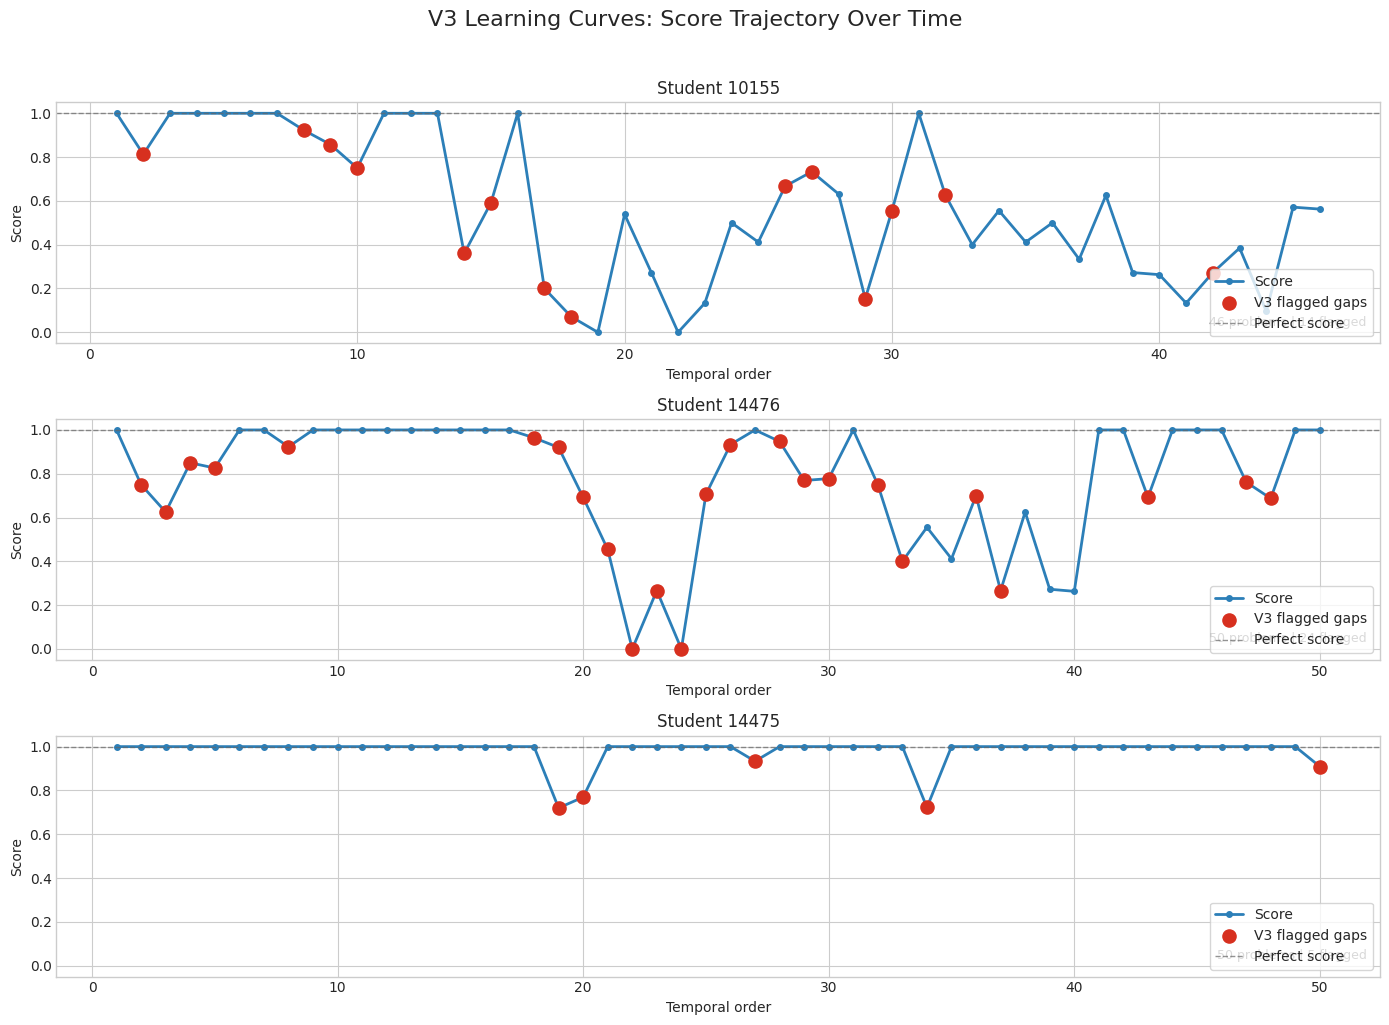

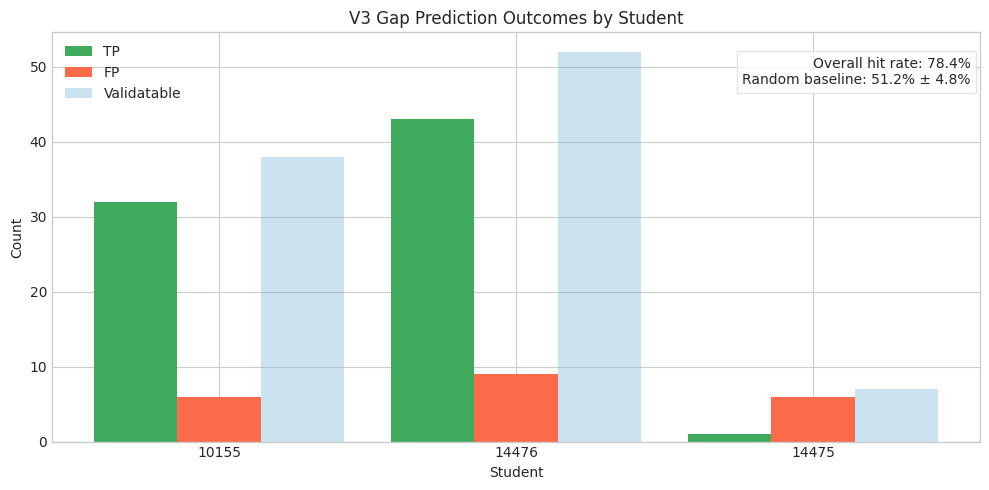

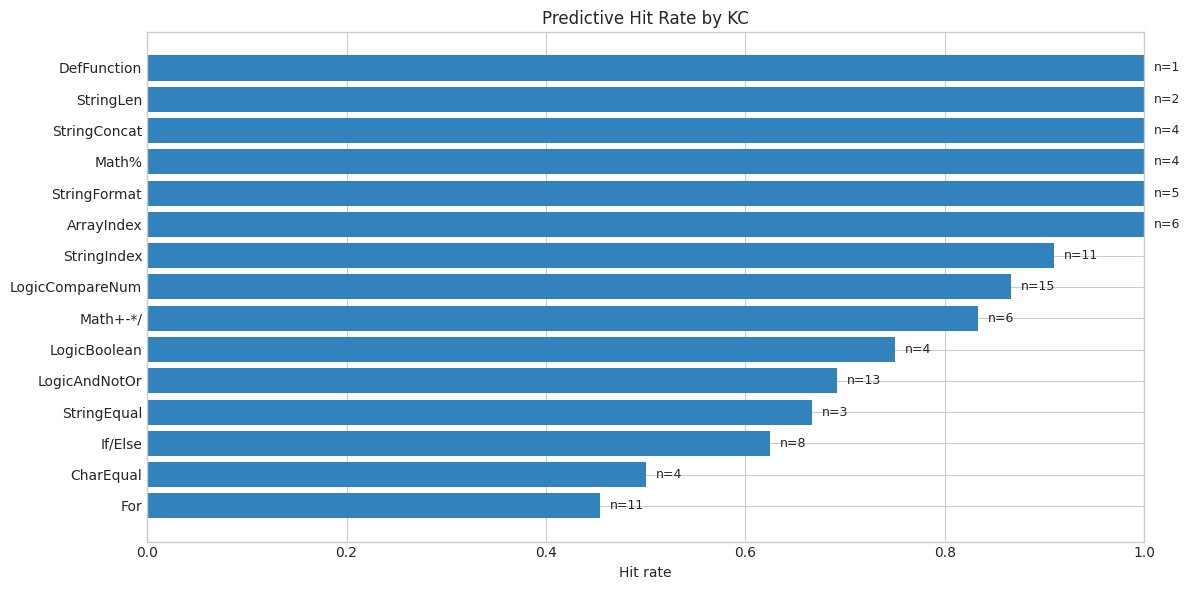

Saved plots to exp15_learning_curve_curves.png, exp15_learning_curve_student_outcomes.png, and exp15_learning_curve_kc_hit_rates.png


In [12]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

curve_rows = []
for sid, problems in all_problems_by_student.items():
    for idx, p in enumerate(problems, start=1):
        curve_rows.append({
            'SubjectID': sid,
            'TemporalOrder': idx,
            'ProblemID': int(p['pid']),
            'Score': p['score'],
            'HadGaps': bool(p['gaps']),
            'GapCount': len(p['gaps']),
            'GapLabels': ', '.join(p['gaps']) if p['gaps'] else '',
        })

curve_df = pd.DataFrame(curve_rows)

fig, axes = plt.subplots(len(TARGET_STUDENTS), 1, figsize=(14, 10), sharex=False, sharey=True)
if len(TARGET_STUDENTS) == 1:
    axes = [axes]

for ax, sid in zip(axes, TARGET_STUDENTS):
    student_curve = curve_df[curve_df['SubjectID'] == sid].sort_values('TemporalOrder')
    ax.plot(
        student_curve['TemporalOrder'],
        student_curve['Score'],
        color='#2c7fb8',
        lw=2,
        marker='o',
        ms=4,
        label='Score',
    )
    gap_points = student_curve[student_curve['HadGaps']]
    if not gap_points.empty:
        ax.scatter(
            gap_points['TemporalOrder'],
            gap_points['Score'],
            s=90,
            color='#d7301f',
            zorder=3,
            label='V3 flagged gaps',
        )
    ax.axhline(1.0, ls='--', lw=1, color='#666666', alpha=0.7, label='Perfect score')
    ax.set_title(f'Student {sid}')
    ax.set_ylabel('Score')
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel('Temporal order')
    ax.text(
        0.99,
        0.06,
        f"{len(student_curve)} problems | {gap_points.shape[0]} flagged",
        transform=ax.transAxes,
        ha='right',
        va='bottom',
        fontsize=9,
        color='#444444',
    )
    ax.legend(loc='lower right', frameon=True)

fig.suptitle('V3 Learning Curves: Score Trajectory Over Time', fontsize=16, y=1.02)
fig.tight_layout()
curve_path = OUTPUT_DIR / 'exp15_learning_curve_curves.png'
fig.savefig(curve_path, dpi=200, bbox_inches='tight')
plt.show()

summary_df = pd.DataFrame(student_summaries)
summary_df['StudentLabel'] = summary_df['SubjectID'].astype(str)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(summary_df))
width = 0.28
ax.bar(x - width, summary_df['TP'], width, label='TP', color='#41ab5d')
ax.bar(x, summary_df['FP'], width, label='FP', color='#fb6a4a')
ax.bar(x + width, summary_df['Validatable'], width, label='Validatable', color='#6baed6', alpha=0.35)
ax.set_xticks(x)
ax.set_xticklabels(summary_df['StudentLabel'])
ax.set_xlabel('Student')
ax.set_ylabel('Count')
ax.set_title('V3 Gap Prediction Outcomes by Student')
ax.legend()
ax.text(
    0.99,
    0.94,
    f"Overall hit rate: {hit_rate:.1%}\nRandom baseline: {rand_mean:.1%} ± {rand_std:.1%}",
    transform=ax.transAxes,
    ha='right',
    va='top',
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='#dddddd'),
)
fig.tight_layout()
student_path = OUTPUT_DIR / 'exp15_learning_curve_student_outcomes.png'
fig.savefig(student_path, dpi=200, bbox_inches='tight')
plt.show()

kc_rows = []
for kc in KC_COLUMNS:
    kc_data = validatable[validatable['GapKC'] == kc]
    if len(kc_data) > 0:
        kc_tp = len(kc_data[kc_data['Prediction'] == 'TP'])
        kc_rows.append({
            'KC': kc,
            'HitRate': kc_tp / len(kc_data),
            'Count': len(kc_data),
        })

kc_df = pd.DataFrame(kc_rows).sort_values(['HitRate', 'Count'], ascending=[True, False])

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(kc_df['KC'], kc_df['HitRate'], color='#3182bd')
ax.set_xlim(0, 1)
ax.set_xlabel('Hit rate')
ax.set_title('Predictive Hit Rate by KC')
for bar, count in zip(bars, kc_df['Count']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2, f'n={count}', va='center', fontsize=9)
fig.tight_layout()
kc_path = OUTPUT_DIR / 'exp15_learning_curve_kc_hit_rates.png'
fig.savefig(kc_path, dpi=200, bbox_inches='tight')
plt.show()

print(f'Saved plots to {curve_path.name}, {student_path.name}, and {kc_path.name}')

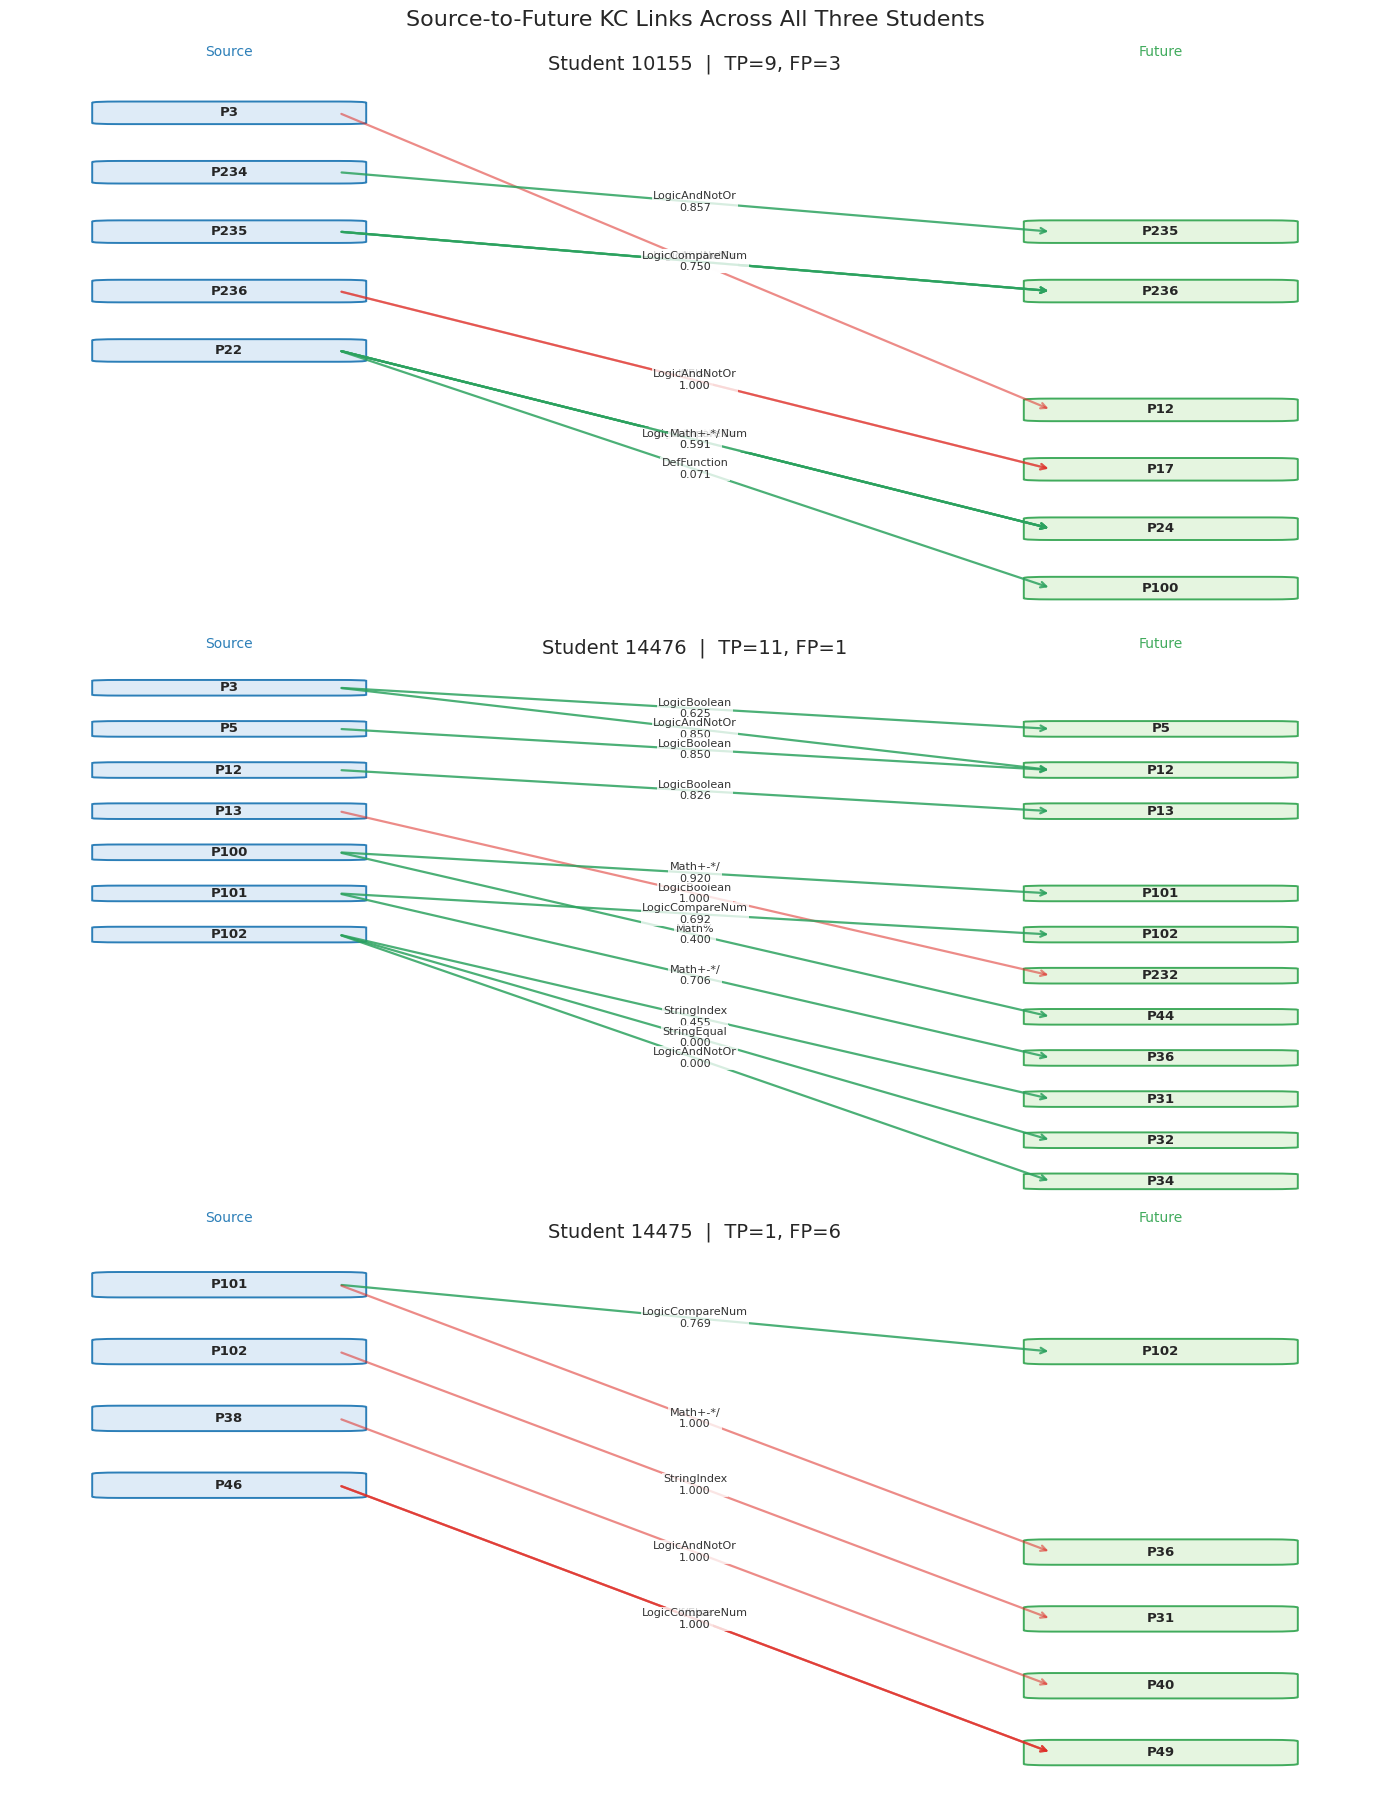

Saved combined KC-link diagram to exp15_kc_link_diagram_all_students.png


In [15]:
# Combined KC-link visualization for all three students.
# Each panel shows source -> future KC links for one student.
import matplotlib.pyplot as plt
import matplotlib.patches as patches

link_df = pd.read_csv(OUTPUT_DIR / 'v3_predictions.csv')
link_df = link_df[link_df['Prediction'].isin(['TP', 'FP'])].copy()

students_to_plot = TARGET_STUDENTS
max_links_per_student = 12

fig, axes = plt.subplots(len(students_to_plot), 1, figsize=(14, 6 * len(students_to_plot)))
if len(students_to_plot) == 1:
    axes = [axes]

for ax, selected_student in zip(axes, students_to_plot):
    student_links = link_df[link_df['SubjectID'] == selected_student].sort_values(['SourceOrder', 'FutureOrder', 'GapKC'])
    if len(student_links) > max_links_per_student:
        student_links = student_links.head(max_links_per_student).copy()

    source_ids = list(dict.fromkeys(student_links['SourceProblem'].astype(int).tolist()))
    future_ids = list(dict.fromkeys(student_links['FutureProblem'].astype(int).tolist()))
    all_ids = source_ids + [pid for pid in future_ids if pid not in source_ids]

    ax.set_xlim(0, 1)
    ax.set_ylim(-0.5, max(0.5, len(all_ids) - 0.5))
    ax.axis('off')

    source_x = 0.16
    future_x = 0.84
    box_w = 0.16
    box_h = 0.34
    y_positions = {pid: len(all_ids) - 1 - idx for idx, pid in enumerate(all_ids)}

    for pid in source_ids:
        y = y_positions[pid]
        rect = patches.FancyBboxPatch(
            (source_x - box_w / 2, y - box_h / 2),
            box_w,
            box_h,
            boxstyle='round,pad=0.02,rounding_size=0.02',
            linewidth=1.4,
            edgecolor='#2c7fb8',
            facecolor='#deebf7',
        )
        ax.add_patch(rect)
        ax.text(source_x, y, f'P{pid}', ha='center', va='center', fontsize=9.5, fontweight='bold')

    for pid in future_ids:
        y = y_positions[pid]
        rect = patches.FancyBboxPatch(
            (future_x - box_w / 2, y - box_h / 2),
            box_w,
            box_h,
            boxstyle='round,pad=0.02,rounding_size=0.02',
            linewidth=1.4,
            edgecolor='#41ab5d',
            facecolor='#e5f5e0',
        )
        ax.add_patch(rect)
        ax.text(future_x, y, f'P{pid}', ha='center', va='center', fontsize=9.5, fontweight='bold')

    ax.text(source_x, len(all_ids) - 0.1 if all_ids else 0.1, 'Source', ha='center', va='bottom', fontsize=10, color='#2c7fb8')
    ax.text(future_x, len(all_ids) - 0.1 if all_ids else 0.1, 'Future', ha='center', va='bottom', fontsize=10, color='#41ab5d')

    for _, row in student_links.iterrows():
        src = int(row['SourceProblem'])
        fut = int(row['FutureProblem'])
        y0 = y_positions[src]
        y1 = y_positions[fut]
        color = '#2ca25f' if row['Prediction'] == 'TP' else '#de2d26'
        alpha = 0.85 if row['Prediction'] == 'TP' else 0.55

        ax.annotate(
            '',
            xy=(future_x - box_w / 2, y1),
            xytext=(source_x + box_w / 2, y0),
            arrowprops=dict(arrowstyle='->', color=color, lw=1.6, alpha=alpha),
        )

        ax.text(
            (source_x + future_x) / 2,
            (y0 + y1) / 2,
            f"{row['GapKC']}\n{row['FutureScore']:.3f}",
            fontsize=8,
            ha='center',
            va='center',
            color='#333333',
            bbox=dict(facecolor='white', alpha=0.78, edgecolor='none', pad=1.0),
        )

    n_tp = int((student_links['Prediction'] == 'TP').sum())
    n_fp = int((student_links['Prediction'] == 'FP').sum())
    ax.set_title(f'Student {selected_student}  |  TP={n_tp}, FP={n_fp}', fontsize=14, pad=10)

fig.suptitle('Source-to-Future KC Links Across All Three Students', fontsize=16, y=0.995)
fig.tight_layout()
combined_link_path = OUTPUT_DIR / 'exp15_kc_link_diagram_all_students.png'
fig.savefig(combined_link_path, dpi=220, bbox_inches='tight')
plt.show()

print(f'Saved combined KC-link diagram to {combined_link_path.name}')